In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate

$$
E + S \rightleftharpoons ES \rightarrow E + P
$$

In [2]:
def model(t, x, k1, k1inv, kcat):
    return np.array([
        - k1 * x[0] * x[1] + k1inv * x[2] + kcat * x[2],
        - k1 * x[0] * x[1] + k1inv * x[2],
        + k1 * x[0] * x[1] - k1inv * x[2] - kcat * x[2],
        + kcat * x[2]
    ])

In [49]:
t = np.linspace(0, 1000, 200)

In [50]:
x0 = np.array([1e-6, 1e-1, 0.0, 0.0])

In [51]:
ks = np.array([1e-1, 1e-2, 1e-3])

In [52]:
solution = integrate.solve_ivp(model, [t.min(), t.max()], y0=x0, args=ks, t_eval=t, atol=1e-16, rtol=1e-12)

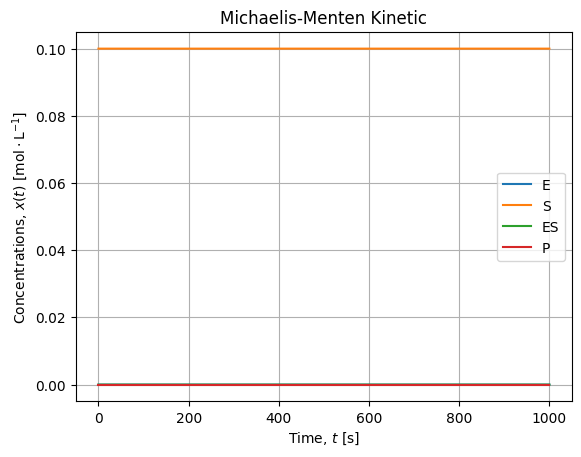

In [58]:
fig, axe = plt.subplots()
axe.plot(t, solution.y.T[:,:])
axe.set_title("Michaelis-Menten Kinetic")
axe.set_xlabel("Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel("Concentrations, $x(t)$ $[\mathrm{mol\cdot L^{-1}}]$")
axe.legend(["E", "S", "ES", "P"])
axe.grid()

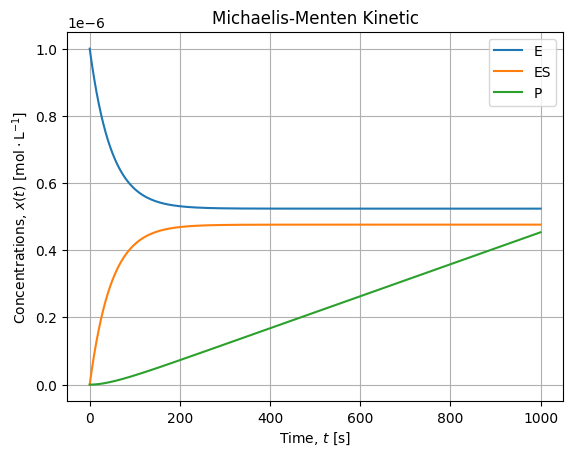

In [55]:
fig, axe = plt.subplots()
axe.plot(t, solution.y.T[:,[0, 2, 3]])
axe.set_title("Michaelis-Menten Kinetic")
axe.set_xlabel("Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel("Concentrations, $x(t)$ $[\mathrm{mol\cdot L^{-1}}]$")
axe.legend(["E", "ES", "P"])
axe.grid()